# ***Model training***

Using the scripts inside `src` directory we can perform any kind of experiment starting from data generation to model evaluation, and drift detection(data, target, concept)

- To maintain consistency in filenames(csv, model, threshold, HTML, png) I have included a seed number during data generation, and it will be there in every filename only if you generate a dataset or use an existing dataset the naming would be for example `filename_seed_xx`.


- Generated the data will be stored inside the `data/simulated` and features will be stored in `data/features` directory.

- Models will store in `artifacts/models` and thresholds will be inside `artifacts/model_threshold` directory.

- Execute the scripts in the following order, don't change it. But it possible to change the parameters of the functions.

## 1. Generate the data for training
This is where all starts, this function will generate 10_000 transactions of 500 users, with a seed number 42 by default. Change the `seed` parameter to get different dataset. It is also possible to change the number of transactions and users.

In [1]:
from fraud_detection import generate_transactions_data

df = generate_transactions_data()
df.head()

/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Name of the csv file: 'simulated_transactions_seed_42.csv'

Data saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/simulated

Generated 10000 transactions.
Fraud rate: 1.48%


,tx_id,timestamp,user_id,amount,category,device_id,auth_method,lat,lon,ip_address,is_fraud
0,e4fd6c34-d67,2026-01-18 15:54:22.044645,user_55,172.43,grocery,475287aa,PIN,-83.615968,174.348649,120.185.31.102,0
1,0cb5ee5c-62f,2026-01-17 18:32:31.182336,user_407,8.43,food,379d58f9,Biometric,20.500359,150.789724,107.109.217.82,0
2,39a0f145-a5b,2026-02-12 04:41:42.270066,user_142,1259.07,tech,bea29dfe,PIN,-87.864685,123.877867,145.56.170.82,0
3,052226b9-836,2026-01-15 20:22:40.850654,user_492,26.14,grocery,052dfb9a,Biometric,-0.992383,-52.469217,208.72.228.108,0
4,a5ba2472-21d,2026-01-25 14:07:42.162645,user_261,364.83,utilities,0d18ab95,Biometric,8.142126,36.488989,104.34.170.221,0


## 2. Perform feature engineering
Just take the name of the csv file with quotes from above cell output and use it as a parameter in feature engineering function, and you will get the model ready features.

In [2]:
from fraud_detection import feature_engineer

df = feature_engineer(
    'simulated_transactions_seed_42.csv'
)

df.head()

Name of the csv file: 'fraud_features_seed_42.csv'

Features saved at: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/features

No of rows: 10000
No of columns: 18


,amount,lat,lon,is_fraud,hour,day_of_week,tx_count_24h,avg_spend_user,amount_ratio,dist_from_last_tx_km,travel_velocity_kmph,auth_method_PIN,auth_method_Password,category_food,category_grocery,category_tech,category_travel,category_utilities
0,347.15,81.605220,-120.226604,0,15,0,1.0,0.000000,0.000000,0.000000,0.0,False,False,False,False,False,False,True
1,232.72,81.664590,-120.236689,0,15,1,2.0,347.150000,0.670373,6.603658,0.0,True,False,False,False,False,False,True
2,260.47,81.612479,-120.228856,0,23,1,2.0,289.935000,0.898374,5.795863,0.0,False,True,False,False,False,False,True
3,103.94,81.600013,-120.252652,0,13,2,3.0,280.113333,0.371064,1.438964,0.0,False,False,True,False,False,False,False
4,2897.77,81.599709,-120.249781,0,3,3,2.0,236.070000,12.275046,0.057599,0.0,False,True,False,False,True,False,False


## 3. Model Training

- Just take the name of the csv file with quotes from above cell output and use it as a parameter in `model_trainer` function.

- `model_trainer` function will return two output one is testing features `X_test` and other one is target `y_test`, keep them for further use. **Don't worry your model(s) will be trained, just click on the directory, you will see it.**

- This `X_test` and `y_test` are holds the default meaning it generally hold (`train_test_split`).

- Currently, there are two algo in the `config.yaml` file, `RandomForestClassifier` and `XGBClassifier`. The script will perform a grid search so it may take some time. Also, it is possible to add another algo in the `config.yaml` file.

In [3]:
from fraud_detection import model_trainer

X_test, y_test = model_trainer(
    'fraud_features_seed_42.csv'
)

Running GridSearch for: random_forest
Model Name: 'random_forest_seed_42.json'
Best Score: 0.9992 | Saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/models
Running GridSearch for: xgboost
Model Name: 'xgboost_seed_42.json'
Best Score: 0.9978 | Saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/models


## 4. Business-cost-aware Thresholding (Threshold Optimization) 
Q. Why is this necessary?

A. Not catching a fraud is much more deadly than blocking a legitimate transaction. ***Considering them as equal, is like commiting war crimes on our customers***.

Inevitably, xgboost treats both of these errors equally because of it's fixed threshold 0.5, ***going down that path would lead us to lose money and trust***.

So we need a custom decision boundary that ***prioritize catching fraud***.

- The variables you put above will be used here in this function `threshold_optimizer` as a parameter.

- `threshold_optimizer` will return two values, first one is probability of that particular model on test data, the second one is using the threshold make a final prediction. Put this two values inside two variables. But don't just use `y_prob` and `y_pred_final` as variable name. Just put the name of the model after underscore `_`.

- Now this two new variable and the previous two variable will be used to evaluate a model.


### a. Optimize threshold xgboost

In [4]:
from fraud_detection import threshold_optimizer

y_prob_xgb , y_pred_final_xgb = threshold_optimizer(
    X_test, 
    y_test, 
    'xgboost_seed_42.json'    
)

Optimal threshold information saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/model_thresholds

The threshold for the model: xgboost_seed_42 is: 0.98


### b. Optimize threshold RandomForest

In [5]:
from fraud_detection import threshold_optimizer

y_prob_rf , y_pred_final_rf = threshold_optimizer(
    X_test,
    y_test,
    'random_forest_seed_42.json'
)

Optimal threshold information saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/model_thresholds

The threshold for the model: random_forest_seed_42 is: 0.39


## 5. Model Evaluation

### a. Evaluate the xgboost model

AUC-PR for xgboost_seed_42.json: 1.0000

Classification Report for xgboost_seed_42.json:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/src/fraud_detection/model_evaluation.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar")


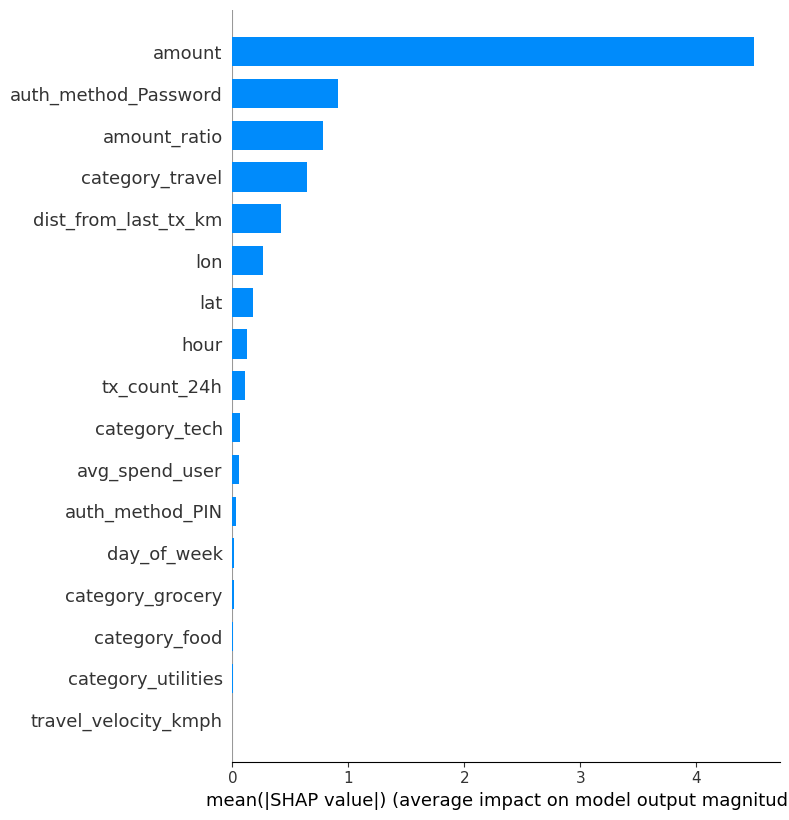

In [6]:
from fraud_detection import model_evaluator

model_evaluator(
    'xgboost_seed_42.json',
    X_test,
    y_test,
    y_prob_xgb,
    y_pred_final_xgb
)

### b. Evaluate the RandomForest Model

AUC-PR for random_forest_seed_42.json: 1.0000

Classification Report for random_forest_seed_42.json:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/src/fraud_detection/model_evaluation.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar")


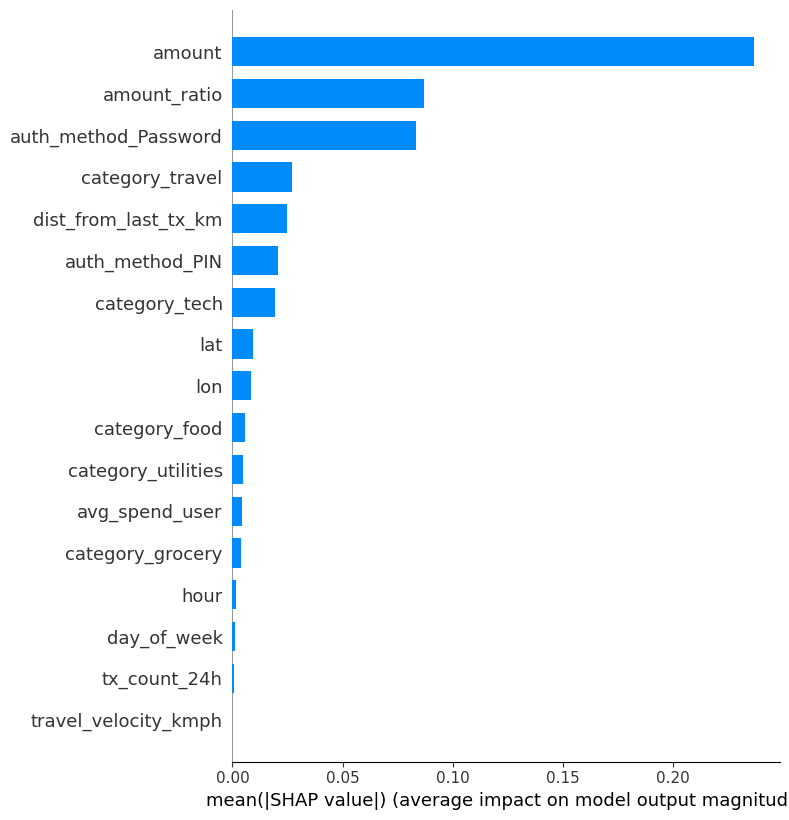

In [7]:
from fraud_detection import model_evaluator

model_evaluator(
    'random_forest_seed_42.json',
    X_test,
    y_test,
    y_prob_rf,
    y_pred_final_rf
)

# ***Testing on a new dataset***

Generate a new dataset with a seed no 69 and evaluate our models

## a. Data generation

In [8]:
from fraud_detection import generate_transactions_data

df_new = generate_transactions_data(
    seed=69
)
df_new.head()

Name of the csv file: 'simulated_transactions_seed_69.csv'

Data saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/simulated

Generated 10000 transactions.
Fraud rate: 1.48%


,tx_id,timestamp,user_id,amount,category,device_id,auth_method,lat,lon,ip_address,is_fraud
0,f9744aec-2a6,2026-02-02 16:01:41.946825,user_427,222.96,entertainment,9cc4db65,Biometric,65.893603,-148.365495,113.66.251.143,0
1,cbabf0a8-f1c,2026-01-10 13:14:31.840429,user_262,136.53,food,d438044a,Password,31.419059,165.176342,23.232.214.17,0
2,e65c2a77-6bd,2026-02-09 17:07:23.154300,user_162,78.84,grocery,98385fe7,Biometric,54.196309,3.579783,53.76.204.35,0
3,226d78a1-36a,2026-01-13 09:51:00.610833,user_267,73.00,utilities,1cdf4a65,Biometric,-42.986678,107.731463,115.65.179.248,0
4,682a4572-c28,2026-01-03 08:10:09.010006,user_276,354.15,entertainment,9d545db5,PIN,81.356313,-151.038827,9.161.1.194,0


## ***Drift detection***

Before we do anything, let's just check if there was any data drift present between the trained data and newly generated data, for each of the model.

### a. Random Forest

In [9]:
from fraud_detection import generate_monitoring_report

drift_stats = generate_monitoring_report(
    model_name= 'random_forest_seed_42.json',
    trained_dataset= 'simulated_transactions_seed_42.csv',
    new_dataset= 'simulated_transactions_seed_69.csv'
)



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fr

Data and Target Drift Monitoring
Status      : No action needed!!!
Drift score : 0.00
Report      : /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/reports/drift_monitoring/drift_report_simulated_transactions_seed_69_vs_simulated_transactions_seed_42_20260212_143954.html


### b. Xgboost

In [10]:
from fraud_detection import generate_monitoring_report

drift_stats = generate_monitoring_report(
    model_name= 'xgboost_seed_42.json',
    trained_dataset= 'simulated_transactions_seed_42.csv',
    new_dataset= 'simulated_transactions_seed_69.csv'
)



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide

/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide

/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_imp

Data and Target Drift Monitoring
Status      : No action needed!!!
Drift score : 0.00
Report      : /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/reports/drift_monitoring/drift_report_simulated_transactions_seed_69_vs_simulated_transactions_seed_42_20260212_144006.html


## b. Feature Engineering

In [11]:
from fraud_detection import feature_engineer

df_new = feature_engineer(
    'simulated_transactions_seed_69.csv'
)

df_new.head()

Name of the csv file: 'fraud_features_seed_69.csv'

Features saved at: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/data/features

No of rows: 10000
No of columns: 18


,amount,lat,lon,is_fraud,hour,day_of_week,tx_count_24h,avg_spend_user,amount_ratio,dist_from_last_tx_km,travel_velocity_kmph,auth_method_PIN,auth_method_Password,category_food,category_grocery,category_tech,category_travel,category_utilities
0,167.52,-80.018972,-128.503529,0,7,6,1.0,0.000000,0.000000,0.000000,0.0,False,False,False,True,False,False,False
1,75.89,-79.978198,-128.498238,0,22,6,2.0,167.520000,0.453021,4.535013,0.0,True,False,False,False,False,False,False
2,69.39,-79.942544,-128.543715,0,21,0,2.0,121.705000,0.570149,4.061371,0.0,False,False,False,False,False,False,False
3,614.22,-79.940534,-128.549401,0,20,1,2.0,104.266667,5.890857,0.249293,0.0,False,False,False,False,True,False,False
4,45.89,-79.960488,-128.532205,0,19,2,2.0,231.755000,0.198011,2.243731,0.0,True,False,True,False,False,False,False


## c. Threshold optimization + Model Prediction

Before threshold optimization, we need to separate the **features** from the **target**.

In [12]:
X_test = df.drop(columns=['is_fraud'])
y_test = df['is_fraud']

### a. Random Forest

In [13]:
from fraud_detection import threshold_optimizer

y_prob_rf, y_pred_final_rf = threshold_optimizer(
    X_test=X_test,
    y_test=y_test,
    model_name='random_forest_seed_42.json'
)


Optimal threshold information saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/model_thresholds

The threshold for the model: random_forest_seed_42 is: 0.43


AUC-PR for random_forest_seed_42.json: 1.0000

Classification Report for random_forest_seed_42.json:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9852
           1       1.00      1.00      1.00       148

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/src/fraud_detection/model_evaluation.py:116: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



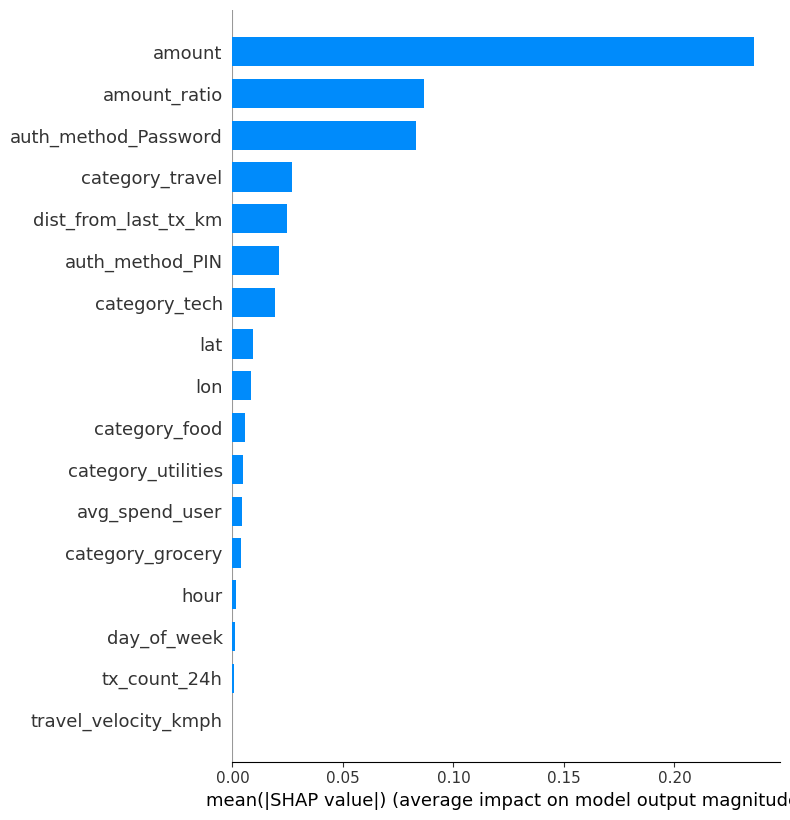

In [14]:
from fraud_detection import model_evaluator

model_evaluator(
    model_name='random_forest_seed_42.json',
    X_test=X_test,
    y_test=y_test,
    y_prob=y_prob_rf,
    y_pred_final=y_pred_final_rf
)

### b. Xgboost

In [15]:
from fraud_detection import threshold_optimizer

y_prob_xgb, y_pred_final_xgb = threshold_optimizer(
    X_test=X_test,
    y_test=y_test,
    model_name='xgboost_seed_42.json'
)


Optimal threshold information saved to: /home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/artifacts/model_thresholds

The threshold for the model: xgboost_seed_42 is: 0.9600000000000001


AUC-PR for xgboost_seed_42.json: 0.9997

Classification Report for xgboost_seed_42.json:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9852
           1       0.99      1.00      0.99       148

    accuracy                           1.00     10000
   macro avg       0.99      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



/home/bs-prime/Documents/Project/Portfolio_projects/Real_Time_Fraud_Detection_System/src/fraud_detection/model_evaluation.py:116: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



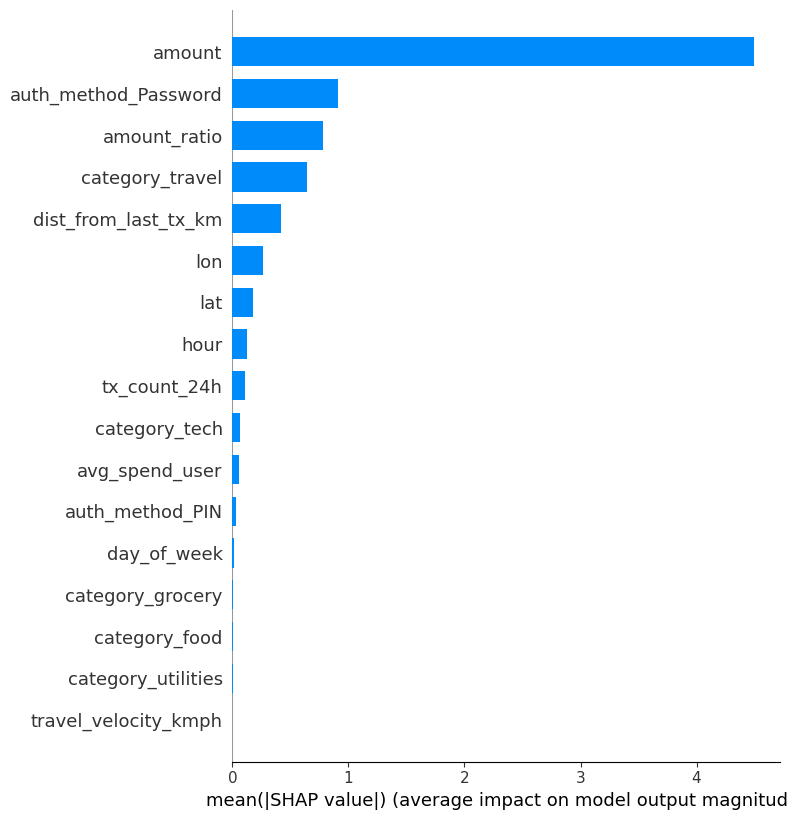

In [16]:
from fraud_detection import model_evaluator

model_evaluator(
    model_name='xgboost_seed_42.json',
    X_test=X_test,
    y_test=y_test,
    y_prob=y_prob_xgb,
    y_pred_final=y_pred_final_xgb
)

> I think instead of training all the models in one single time, I should just change the `model_training` script to have one at a time. While I am doing that I could just convert all of this scripts into a training pipeline. It would be much more scalable and clutter free option.

# **Final Conclusion**

Although both XGBoost and RandomForestClassifier achieved comparable performance with near-perfect classification results, XGBoost was selected for deployment due to its superior inference efficiency and production-ready architecture.

The model is deployed using XGBoost’s native Booster interface, a lightweight low-level container that directly stores the trained trees, parameters, and configuration. This allows predictions to be executed by XGBoost’s optimized native engine without the overhead introduced by higher-level wrappers.

This approach provides several deployment advantages, including faster inference speed, lower memory overhead, faster model loading through native serialization, and improved CPU cache efficiency due to XGBoost’s compact tree representation.

In contrast, RandomForestClassifier, while equally accurate, relies on independently stored trees without the same level of execution optimization, resulting in comparatively higher inference latency.

Therefore, XGBoost was selected not for improved predictive performance, but for its superior operational efficiency, lower latency, and stronger suitability for real-time production API environments.